In [192]:
import pandas as pd
from sqlalchemy import create_engine, inspect
from sqlalchemy.orm import sessionmaker
import matplotlib.pyplot as plt

In [193]:
# connect to the database
db_path = "/home/locascio/mydata/YServer/experiments/rchrono_comments.db"
engine = create_engine(f"sqlite:///{db_path}")

In [194]:
# Inspect Database Structure

inspector = inspect(engine)
table_names = inspector.get_table_names()
print("Tables in the database:")
print(table_names)

Tables in the database:
['article_topics', 'articles', 'emotions', 'follow', 'hashtags', 'images', 'interests', 'mentions', 'post', 'post_emotions', 'post_hashtags', 'post_topics', 'reactions', 'recommendations', 'rounds', 'user_interest', 'user_mgmt', 'voting', 'websites']


In [195]:
if "post" in table_names:
    # Load the data
    topics_interactions_df = pd.read_sql_query("SELECT interests.interest AS topic, post.user_id, post.round FROM post JOIN post_topics ON post.id = post_topics.post_id JOIN interests ON interests.iid = post_topics.topic_id", engine)
    topics_interactions_df['type'] = 'post'
else:
    raise ValueError("table not found in the database.")

print("First 5 rows:")
print(topics_interactions_df.head())

# Basic statistics
print("Summary statistics of numeric columns:")
print(topics_interactions_df.describe())

First 5 rows:
                   topic  user_id  round  type
0           unusual pets      419      1  post
1      extreme gardening       22      1  post
2           baking bread       22      1  post
3  silly political facts       70      1  post
4           unusual pets       70      1  post
Summary statistics of numeric columns:
           user_id        round
count  2281.000000  2281.000000
mean    250.720737   356.089434
std     141.693949   209.945195
min       1.000000     1.000000
25%     130.000000   170.000000
50%     257.000000   350.000000
75%     368.000000   544.000000
max     498.000000   719.000000


In [196]:
if "reactions" in table_names:
    # Load the data
    reactions_df = pd.read_sql_query("SELECT reactions.type, reactions.user_id, reactions.round, interests.interest AS topic FROM post_topics JOIN reactions ON reactions.post_id = post_topics.post_id JOIN interests ON interests.iid = post_topics.topic_id", engine)
else:
    raise ValueError("table not found in the database.")

print("First 5 rows:")
print(reactions_df.head())

# Basic statistics
print("Summary statistics of numeric columns:")
print(reactions_df.describe())

First 5 rows:
      type  user_id  round         topic
0  dislike       37     35  unusual pets
1  dislike      119     30  unusual pets
2  dislike      127     35  unusual pets
3  dislike      143     17  unusual pets
4  dislike      164      1  unusual pets
Summary statistics of numeric columns:
          user_id       round
count  311.000000  311.000000
mean   258.627010  304.176849
std    133.605301  257.708370
min      4.000000    1.000000
25%    141.500000   25.000000
50%    277.000000  308.000000
75%    374.000000  553.000000
max    489.000000  719.000000


In [197]:
total_df = pd.concat([topics_interactions_df, reactions_df], axis=0)
total_df = total_df.sort_values('round')
total_df

,topic,user_id,round,type
6,extreme gardening,84,1,post
4,unusual pets,70,1,post
5,extreme gardening,84,1,post
0,unusual pets,419,1,post
1,extreme gardening,22,1,post
...,...,...,...,...
2279,street photography,267,718,post
2278,baking bread,267,718,post
305,unusual pets,213,719,dislike
304,street photography,213,719,dislike


In [198]:
df = total_df
rounds = 24
days = 7
weeks = 5

steps = rounds
# steps = rounds*days
# steps = rounds*days*weeks

In [199]:
# Create a grouping column by dividing the round by 24
df['group'] = (df['round'] - 1) // steps

grouped = df.groupby(by=['group', 'user_id', 'topic']).size().reset_index(name='count')

# order by group and user_id and count
grouped = grouped.sort_values(by=['group',  'count', 'user_id'], ascending=[True, False, True])

grouped

,group,user_id,topic,count
3,0,15,extreme gardening,2
7,0,21,extreme gardening,2
25,0,84,extreme gardening,2
31,0,123,extreme gardening,2
33,0,128,street photography,2
...,...,...,...,...
2222,29,426,extreme gardening,1
2223,29,446,unusual pets,1
2224,29,456,extreme gardening,1
2225,29,487,extreme gardening,1


In [200]:
# show the most common topic for each group
grouped_common = df.groupby(by=['group', 'topic']).size().reset_index(name='count')
grouped_common = grouped_common.sort_values(by=['group', 'count'], ascending=[True, False])
grouped_common = grouped_common.drop_duplicates(subset='group', keep='first')
grouped_common

,group,topic,count
1,0,extreme gardening,40
9,1,unusual pets,26
11,2,extreme gardening,27
19,3,unusual pets,19
20,4,baking bread,22
28,5,street photography,21
33,6,street photography,27
38,7,street photography,20
40,8,baking bread,23
48,9,street photography,17


In [201]:
# show the top 2 topics for each user in each group
grouped_top_topics =  df.groupby(by=['group', 'user_id', 'topic']).size().reset_index(name='count')
# Sort by group, user_id, and count in descending order
grouped_top_topics = grouped_top_topics.sort_values(
    by=['group', 'user_id', 'count'], ascending=[True, True, False]
)

# Select the top 2 topics for each user in each group
grouped_top_topics = grouped_top_topics.groupby(['group', 'user_id']).head(2)
grouped_top_topics = grouped_top_topics.sort_values(by=['group', 'user_id'], ascending=[True, True])

grouped_top_topics


,group,user_id,topic,count
0,0,13,silly political facts,1
1,0,13,street photography,1
3,0,15,extreme gardening,2
4,0,20,baking bread,1
5,0,20,extreme gardening,1
...,...,...,...,...
2222,29,426,extreme gardening,1
2223,29,446,unusual pets,1
2224,29,456,extreme gardening,1
2225,29,487,extreme gardening,1


In [202]:
df[df['user_id'] == 4]

,topic,user_id,round,type,group
164,street photography,4,51,post,2
165,street photography,4,51,post,2
257,street photography,4,626,dislike,26
256,baking bread,4,626,dislike,26


/tmp/ipykernel_2366210/945123306.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Topics", bbox_to_anchor=(1.05, 1), loc='upper left')


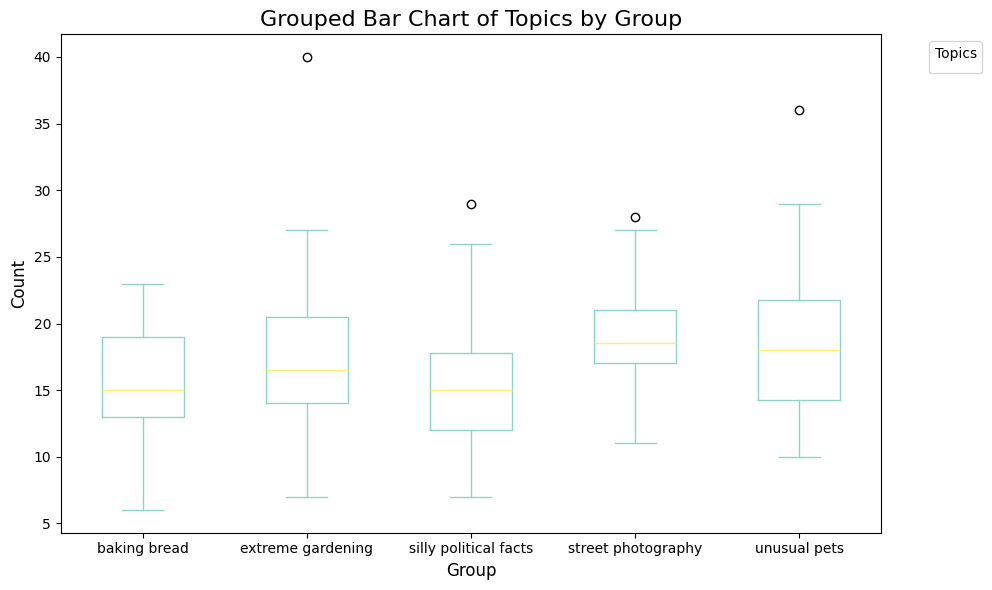

In [204]:
grouped_count = df.groupby(by=['group', 'topic']).size().reset_index(name='count')
grouped_count

# Pivot the data to prepare for grouped bar chart
pivot_df = grouped_count.pivot(index="group", columns="topic", values="count")

# Plot grouped bar chart
ax = pivot_df.plot(kind="box", figsize=(10, 6), colormap='Set3')

# Add labels and title
plt.title("Grouped Bar Chart of Topics by Group", fontsize=16)
plt.xlabel("Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Topics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Display the chart
plt.show()